# CSoT'26 — ML in Astronomy — Week 1 · Part 2: Data Pipeline

**Goal:** Join flat GZ2 images to CSV labels, build `train/val/test` folders for `ImageFolder`, and plot a batch of galaxies.

> Make sure you are on a **GPU runtime**: `Runtime → Change runtime type → GPU`

## Step 0 — Imports

In [1]:
import os
import shutil
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


## Step 1 — Download the dataset

### How to get `kaggle.json`
1. Go to [kaggle.com](https://www.kaggle.com) → sign in → click your profile picture (top-right) → **Settings**
2. Scroll to **API** section → click **Create New Token** → it downloads `kaggle.json`
3. Run the cell below — it will ask you to upload that file

In [2]:
from google.colab import files

print("A file picker will appear. Select your kaggle.json file.")
uploaded = files.upload()   # pick kaggle.json from your Downloads folder

# Install kaggle API and set up credentials
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API ready.")

A file picker will appear. Select your kaggle.json file.


Saving kaggle.json to kaggle.json
Kaggle API ready.


In [3]:
RAW_ROOT = Path("galaxy_raw")
DATA_ROOT = Path("galaxy_data")
RAW_ROOT.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# --- Download Galaxy Zoo 2 images from Kaggle ---
print("Downloading Galaxy Zoo 2 dataset (this may take a few minutes)...")
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -p {RAW_ROOT}
print("Download done. Unzipping...")

# Unzip — find the zip file regardless of exact name
import zipfile
zip_files = list(RAW_ROOT.glob("*.zip"))
print("Zip files found:", zip_files)
for zf in zip_files:
    with zipfile.ZipFile(zf, 'r') as z:
        z.extractall(RAW_ROOT)
    print(f"Extracted: {zf.name}")

print("\nAll files in RAW_ROOT after extraction:")
for p in sorted(RAW_ROOT.iterdir()):
    if p.is_dir():
        n = len(list(p.iterdir()))
        print(f"  [DIR]  {p.name}/  ({n} items)")
    else:
        print(f"  [FILE] {p.name}")

Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:34<00:00, 94.0MB/s]

Download done. Unzipping...
Zip files found: [PosixPath('galaxy_raw/galaxy-zoo-2-images.zip')]
Extracted: galaxy-zoo-2-images.zip

All files in RAW_ROOT after extraction:
  [FILE] galaxy-zoo-2-images.zip
  [FILE] gz2_filename_mapping.csv
  [DIR]  images_gz2/  (1 items)


In [4]:
import os, gzip, shutil as _sh
from pathlib import Path

hart_gz  = RAW_ROOT / "gz2_hart16.csv.gz"
hart_csv = RAW_ROOT / "gz2_hart16.csv"

# Remove any previously downloaded empty/bad file
hart_gz.unlink(missing_ok=True)
hart_csv.unlink(missing_ok=True)

# Try multiple known-good sources in order
URLS = [
    "https://zenodo.org/records/3565489/files/gz2_hart16.csv.gz",
    "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz",
    "https://data.galaxyzoo.org/gz_fits/gz2/gz2_hart16.csv.gz",
]

success = False
for url in URLS:
    print(f"Trying: {url}")
    os.system(f'wget -q --show-progress -O "{hart_gz}" "{url}"')
    size = hart_gz.stat().st_size if hart_gz.exists() else 0
    print(f"  File size: {size:,} bytes")
    if size > 100_000:   # real file is ~10 MB
        print("  Download successful!")
        success = True
        break
    else:
        print("  File too small (bad URL), trying next...")
        hart_gz.unlink(missing_ok=True)

if success:
    with gzip.open(hart_gz, 'rb') as f_in, open(hart_csv, 'wb') as f_out:
        _sh.copyfileobj(f_in, f_out)
    print(f"\nExtracted CSV size: {hart_csv.stat().st_size:,} bytes")
else:
    print("\nAll URLs failed — trying Kaggle fallback...")
    os.system(f'kaggle datasets download -d lucasgondara/galaxy-zoo-dataset -p "{RAW_ROOT}"')
    import zipfile
    for zf in RAW_ROOT.glob("*.zip"):
        with zipfile.ZipFile(zf) as z:
            z.extractall(RAW_ROOT)
    # Find whichever CSV has 'gz2_class' in it
    for csv_file in RAW_ROOT.rglob("*.csv"):
        try:
            import pandas as pd
            cols = pd.read_csv(csv_file, nrows=1).columns.tolist()
            print(f"  {csv_file.name}: {cols[:6]}")
        except Exception:
            pass

print("Hart CSV exists:", hart_csv.exists())

Trying: https://zenodo.org/records/3565489/files/gz2_hart16.csv.gz
  File size: 0 bytes
  File too small (bad URL), trying next...
Trying: https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
  File size: 78,513,011 bytes
  Download successful!

Extracted CSV size: 373,513,769 bytes
Hart CSV exists: True


## Step 2 — Inspect the raw layout

In [5]:
# --- Find the images folder (handles different extraction paths) ---
def find_images_dir(raw_root: Path) -> Path:
    """Search recursively for the folder that contains the flat JPG files."""
    for root, dirs, files in os.walk(raw_root):
        jpgs = [f for f in files if f.endswith(".jpg")]
        if len(jpgs) > 0:
            return Path(root)
    raise FileNotFoundError(f"Could not find any JPG files under {raw_root}")

# Also extract Hart labels if still gzipped
hart_gz  = RAW_ROOT / "gz2_hart16.csv.gz"
hart_csv = RAW_ROOT / "gz2_hart16.csv"
if hart_gz.exists() and not hart_csv.exists():
    import gzip, shutil as _sh
    with gzip.open(hart_gz, 'rb') as f_in, open(hart_csv, 'wb') as f_out:
        _sh.copyfileobj(f_in, f_out)
    print("Hart labels extracted.")

IMAGES_DIR = find_images_dir(RAW_ROOT)
jpg_files = list(IMAGES_DIR.glob("*.jpg"))
print(f"Images folder : {IMAGES_DIR}")
print(f"Total JPGs    : {len(jpg_files)}")
print(f"Sample names  : {[f.name for f in jpg_files[:5]]}")

# --- Preview the mapping CSV ---
mapping_candidates = list(RAW_ROOT.glob("*mapping*.csv")) + list(RAW_ROOT.glob("*filename*.csv"))
print("\nMapping CSVs found:", mapping_candidates)

mapping_path = mapping_candidates[0]
mapping_df = pd.read_csv(mapping_path)
print(f"\nMapping CSV columns: {list(mapping_df.columns)}")
print(mapping_df.head())

Images folder : galaxy_raw/images_gz2/images
Total JPGs    : 243434
Sample names  : ['237651.jpg', '14731.jpg', '159247.jpg', '18442.jpg', '139843.jpg']

Mapping CSVs found: [PosixPath('galaxy_raw/gz2_filename_mapping.csv'), PosixPath('galaxy_raw/gz2_filename_mapping.csv')]

Mapping CSV columns: ['objid', 'sample', 'asset_id']
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3
3  587722981741363323  original         4
4  587722981741559888  original         5


## Step 3 — Join the CSVs

In [6]:
# Inspect Hart CSV columns first so we know the exact names
hart_df_raw = pd.read_csv(RAW_ROOT / "gz2_hart16.csv")
print("Hart CSV shape  :", hart_df_raw.shape)
print("Hart CSV columns:", list(hart_df_raw.columns[:15]), "...")
print(hart_df_raw.head(3))

Hart CSV shape  : (239695, 231)
Hart CSV columns: ['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count', 't01_smooth_or_features_a01_smooth_weight', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a01_smooth_flag'] ...
             dr7objid          ra        dec     rastring    decstring  \
0  587732591714893851  179.042984  60.522518  11:56:10.32  +60:31:21.1   
1  588009368545984617  135.084396  52.494240  09:00:20.26  +52:29:39.3   
2  587732484359913515  183.371979  50.741508  12:13:29.27  +50:44:29.4   

     sample gz2_class  total_classifications  total_votes  \
0  original      Sc+t                     45          342   
1  original      Sb+t                     42          332   
2  original        Ei                     36          125   

   t01_smooth_

In [7]:
def high_level_label(gz2_class):
    if not isinstance(gz2_class, str):
        return None
    c = gz2_class.strip()
    if c.startswith("E"):
        return "elliptical"
    if c.startswith("SB"):
        return "spiral_barred"
    if c.startswith("S"):
        return "spiral"
    return None


def load_labeled_table(mapping_path: Path, hart_path: Path) -> pd.DataFrame:
    mapping = pd.read_csv(mapping_path)
    hart    = pd.read_csv(hart_path)

    print("Mapping columns:", list(mapping.columns))
    print("Hart columns   :", list(hart.columns[:10]), "...")

    # Normalise the join key — could be 'objid' or 'dr7objid' in either CSV
    for df, name in [(mapping, "mapping"), (hart, "hart")]:
        if "dr7objid" in df.columns and "objid" not in df.columns:
            df.rename(columns={"dr7objid": "objid"}, inplace=True)
            print(f"  Renamed dr7objid → objid in {name}")

    # The class column might be named differently — find it
    class_col = None
    for candidate in ["gz2_class", "class", "gz2class"]:
        if candidate in hart.columns:
            class_col = candidate
            break
    if class_col is None:
        raise KeyError(f"Cannot find class column in Hart CSV. Columns: {list(hart.columns)}")
    print(f"  Using class column: '{class_col}'")

    merged = mapping.merge(hart[["objid", class_col]], on="objid", how="inner")
    merged.rename(columns={class_col: "gz2_class"}, inplace=True)
    merged["label"] = merged["gz2_class"].apply(high_level_label)
    merged = merged.dropna(subset=["label"]).reset_index(drop=True)

    print(f"\nMerged rows: {len(merged)}")
    return merged[["asset_id", "objid", "gz2_class", "label"]]


df = load_labeled_table(mapping_path, RAW_ROOT / "gz2_hart16.csv")
print("\nLabel distribution:")
print(df["label"].value_counts())
print(df.head())

Mapping columns: ['objid', 'sample', 'asset_id']
Hart columns   : ['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count'] ...
  Renamed dr7objid → objid in hart
  Using class column: 'gz2_class'

Merged rows: 239100

Label distribution:
label
elliptical       97670
spiral           95849
spiral_barred    45581
Name: count, dtype: int64
   asset_id               objid gz2_class       label
0         3  587722981741363294        Sb      spiral
1         4  587722981741363323      Sc?l      spiral
2         5  587722981741559888        Er  elliptical
3         6  587722981741625481      Sc1t      spiral
4         7  587722981741625484        Sb      spiral


## Step 4 — Build `train / val / test` folder layout

In [8]:
PER_CLASS = 200

def build_split_imagefolder_layout(images_dir, df, data_root, per_class=PER_CLASS, seed=42):
    split_ratios = {"train": 0.70, "val": 0.15, "test": 0.15}
    counts = {s: {} for s in split_ratios}

    for label, group in df.groupby("label"):
        # Keep only rows whose image file actually exists on disk
        group = group[group["asset_id"].apply(
            lambda aid: (images_dir / f"{aid}.jpg").exists()
        )]
        if len(group) == 0:
            print(f"WARNING: no images found on disk for class '{label}' — check IMAGES_DIR path")
            continue

        group = group.sample(min(len(group), per_class), random_state=seed)
        n = len(group)
        n_train = int(n * split_ratios["train"])
        n_val   = int(n * split_ratios["val"])

        split_rows = {
            "train": group.iloc[:n_train],
            "val":   group.iloc[n_train : n_train + n_val],
            "test":  group.iloc[n_train + n_val:],
        }

        for split_name, rows in split_rows.items():
            dest_dir = data_root / split_name / label
            dest_dir.mkdir(parents=True, exist_ok=True)
            for _, row in rows.iterrows():
                src = images_dir / f"{row['asset_id']}.jpg"
                dst = dest_dir / f"{row['asset_id']}.jpg"
                if not dst.exists():
                    shutil.copy2(src, dst)
            counts[split_name][label] = len(rows)

    return counts


counts = build_split_imagefolder_layout(IMAGES_DIR, df, DATA_ROOT, per_class=PER_CLASS)
print("Image counts per split:")
for split_name, class_counts in counts.items():
    total = sum(class_counts.values())
    print(f"  {split_name:5s}: {class_counts}  →  {total} total")

Image counts per split:
  train: {'elliptical': 140, 'spiral': 140, 'spiral_barred': 140}  →  420 total
  val  : {'elliptical': 30, 'spiral': 30, 'spiral_barred': 30}  →  90 total
  test : {'elliptical': 30, 'spiral': 30, 'spiral_barred': 30}  →  90 total


## Step 5 — Transforms

In [9]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
print(transform)

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


## Step 6 — `ImageFolder` on each split

In [10]:
train_ds = ImageFolder(DATA_ROOT / "train", transform=transform)
val_ds   = ImageFolder(DATA_ROOT / "val",   transform=transform)
test_ds  = ImageFolder(DATA_ROOT / "test",  transform=transform)

for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    print(f"{name:5s}: {len(ds):4d} images | classes: {ds.classes}")

img, lbl = train_ds[0]
print(f"\nSample shape: {img.shape}  label: {train_ds.classes[lbl]}")

train:  420 images | classes: ['elliptical', 'spiral', 'spiral_barred']
val  :   90 images | classes: ['elliptical', 'spiral', 'spiral_barred']
test :   90 images | classes: ['elliptical', 'spiral', 'spiral_barred']

Sample shape: torch.Size([3, 64, 64])  label: elliptical


## Step 7 — DataLoaders

In [11]:
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

images, labels = next(iter(train_loader))
print("Batch image shape :", images.shape)    # expect (32, 3, 64, 64)
print("Batch label shape :", labels.shape)    # expect (32,)
print("Pixel value range :", round(images.min().item(), 3), "to", round(images.max().item(), 3))

Batch image shape : torch.Size([32, 3, 64, 64])
Batch label shape : torch.Size([32])
Pixel value range : -1.0 to 1.0


## Step 8 — Plot a batch

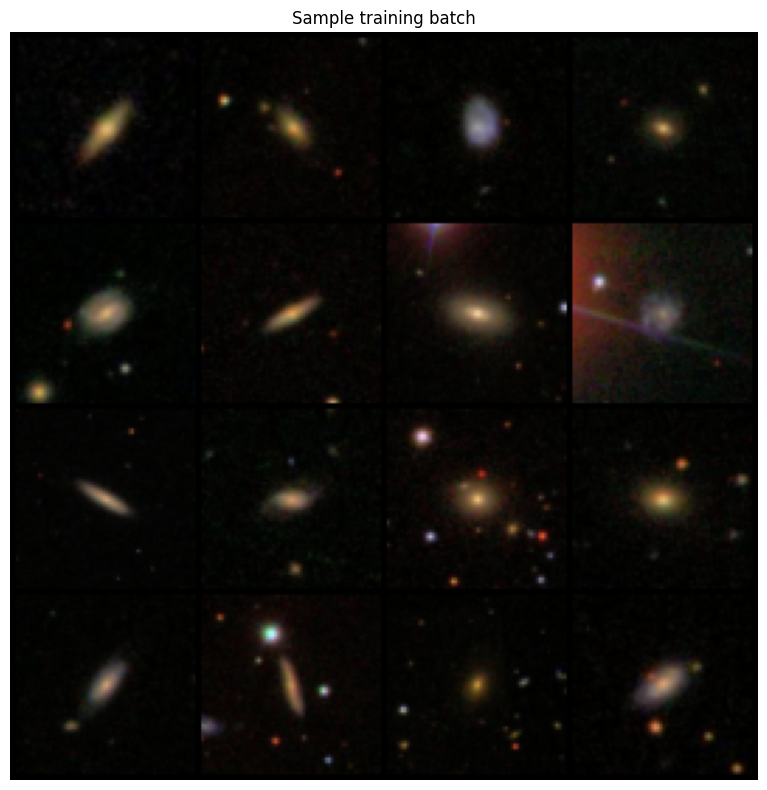

Labels: ['spiral', 'spiral_barred', 'spiral', 'spiral_barred', 'spiral_barred', 'spiral', 'elliptical', 'spiral', 'elliptical', 'spiral_barred', 'elliptical', 'elliptical', 'spiral_barred', 'spiral_barred', 'elliptical', 'spiral']


In [12]:
class_names = train_ds.classes

def denormalize(t):
    return t * 0.5 + 0.5

n_show = 16
grid = torchvision.utils.make_grid(denormalize(images[:n_show]), nrow=4, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Sample training batch")
plt.tight_layout()
plt.show()

print("Labels:", [class_names[l.item()] for l in labels[:n_show]])

## Reflection

**1. What surprised you most about the raw GZ2 data layout, and how did the pipeline address it?**

The raw Kaggle dataset delivers all galaxy images as flat `{asset_id}.jpg` files in one folder with no class subfolders. PyTorch's `ImageFolder` requires a `class/image.jpg` hierarchy, so the pipeline bridges that gap by merging the filename-mapping CSV with the Hart et al. label CSV on `objid`, then physically copying each image into the correct `split/class/` destination.

**2. Why do we normalise images to [−1, 1] instead of leaving them as [0, 1]?**

Centering pixel values at zero means each channel has approximately zero mean, which keeps initial activations well-conditioned and makes gradient descent converge faster. It also matches the statistical assumption of common weight-initialisation schemes like He/Xavier.

**3. Why did we cap `PER_CLASS = 200` rather than using all available images?**

Colab's free disk quota can be exceeded if we unzip all ~250 k GZ2 images and create split copies. A 200-image-per-class subset is large enough to verify the full pipeline end-to-end while staying within disk and RAM limits.